In [7]:
# import sys
# !{sys.executable} -m pip install -q Pillow

In [8]:
import sys
import os

# Add parent directory of L3 to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [9]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.text import tokenizer_from_json

from L1.LibLv1 import create_efficientnet_models, load_model_from_weights_and_compile
from L2.LibLv2 import create_autoencoder
from LibLv3 import CNN_Encoder, RNN_Decoder, build_feature_extraction_model, load_tokenizer, evaluate, plot_attention, caption_and_display_image

In [10]:
def extract_efficientnet_version(weights_path):
    match = re.search(r'EfficientNet(B[0-7])', os.path.basename(weights_path))
    return match.group(1) if match else 'B0'

def run_pipeline(image_paths, classifier_weights, autoencoder_weights, caption_model_path,
                 tokenizer_path='tokenizer.json',
                 class_names=['Not Photo', 'Photo'],
                 image_size=(224, 224),
                 gpu_device='/GPU:1'):
    """
    Pipeline: EfficientNet classification, autoencoder enhancement, and captioning with attention.
    """
    print("\n==========================")
    print("📦 Starting Inference Pipeline")
    print("==========================\n")

    if isinstance(image_paths, str):
        image_paths = [image_paths]

    version = extract_efficientnet_version(classifier_weights)

    with tf.device(gpu_device):
        # ------------------------ Load Models ------------------------
        print("🔍 [Model 1: Loading EfficientNet Classifier]")
        classifier = create_efficientnet_models(
            input_shape=(*image_size, 3),
            class_count=len(class_names),
            version=version,
            dropout_rate=0.3,
            fine_tune_at=-1
        )
        classifier = load_model_from_weights_and_compile(classifier, classifier_weights)
        if classifier is None:
            print("❌ Could not load classifier model.")
            return

        print("✨ [Model 2: Loading Autoencoder]")
        autoencoder = create_autoencoder((*image_size, 3))
        try:
            autoencoder.load_weights(autoencoder_weights)
            print("✅ Autoencoder weights loaded.\n")
        except Exception as e:
            print(f"❌ Failed to load autoencoder weights: {e}")
            return

        print("🖼️ [Model 3: Loading Captioning Models]")
        encoder = CNN_Encoder(256)
        decoder = RNN_Decoder(256, 512, 5001)
        ckpt = tf.train.Checkpoint(encoder=encoder, decoder=decoder)
        ckpt_manager = tf.train.CheckpointManager(ckpt, caption_model_path, max_to_keep=5)
        if ckpt_manager.latest_checkpoint:
            ckpt.restore(ckpt_manager.latest_checkpoint)
            print("✅ Captioning model loaded.")

        tokenizer = load_tokenizer(tokenizer_path)
        feature_model = build_feature_extraction_model()

        images_raw, images_array, predictions = [], [], []

        # ------------------------ STEP 1: Classification ------------------------
        print("\n============================")
        print("🔍 STEP 1: Classification with Model 1")
        print("============================\n")

        for path in image_paths:
            img_raw = image.load_img(path, target_size=image_size)
            img_array = image.img_to_array(img_raw)
            img_batch = np.expand_dims(preprocess_input(img_array.copy()), axis=0)

            pred = classifier.predict(img_batch)
            class_idx = np.argmax(pred[0])
            class_label = class_names[class_idx]
            confidence = pred[0][class_idx]

            predictions.append((class_label, confidence))
            images_raw.append(img_raw)
            images_array.append(img_array)

            print(f"🖼️ {os.path.basename(path)} → {class_label} ({confidence:.2%})")

        # Visual display of predictions
        for img, (label, conf) in zip(images_raw, predictions):
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.title(f"[Model 1] {label} ({conf:.2%})")
            plt.axis("off")
            plt.show()

        # ------------------------ STEP 2: Enhancement ------------------------
        print("\n============================")
        print("✨ STEP 2: Enhancement with Model 2")
        print("============================\n")

        for i, (label, _) in enumerate(predictions):
            if label != 'Photo':
                print(f"🚫 Skipping {os.path.basename(image_paths[i])} (Not Photo)")
                continue

            img_array = images_array[i]
            img_batch = np.expand_dims(img_array / 255.0, axis=0)
            enhanced = autoencoder.predict(img_batch)[0]

            plt.figure(figsize=(10, 4))

            plt.subplot(1, 2, 1)
            plt.imshow(img_array.astype("uint8"))
            plt.title("Model 2 Input (Original)")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(enhanced)
            plt.title("Model 2 Output (Enhanced)")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            # ------------------------ STEP 3: Captioning with Attention ------------------------
            """
            STEP 3: Generate a caption using encoder-decoder and visualize attention.
            """
            print("\n============================")
            print("📝 STEP 3: Captioning with Attention")
            print("============================\n")
            result, attention_plot = evaluate(image_paths[i], encoder, decoder, tokenizer, feature_model)
            print('Custom caption:', ' '.join(result))
            plot_attention(image_paths[i], result, attention_plot)

            print('Integration Hugging face:\n')
            caption_and_display_image(image_paths[i])

In [11]:
import glob

folder_path = "test_images"
image_list = glob.glob(f"{folder_path}/*.jpg")



📦 Starting Inference Pipeline

🔍 [Model 1: Loading EfficientNet Classifier]
Fine-tuning activé à partir de la couche -1.
Poids chargés avec succès depuis models\\EfficientNetB1_Bin_best_weights.h5
Modèle compilé avec succès.
✨ [Model 2: Loading Autoencoder]
✅ Autoencoder weights loaded.

🖼️ [Model 3: Loading Captioning Models]

🔍 STEP 1: Classification with Model 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
🖼️ chantier.jpg → Photo (96.77%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
🖼️ COCO_train2014_000000000025.jpg → Photo (99.77%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
🖼️ lorenzo.jpg → Not Photo (100.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
🖼️ matrix.jpg → Not Photo (100.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
🖼️ oLIVIER.jpg → Photo (99.96%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
🖼️ signature_ahmed.jpg → Not Photo (99.96%)


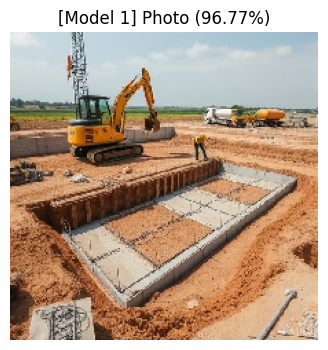

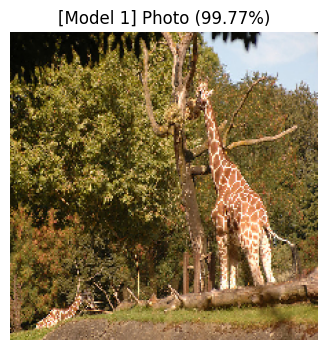

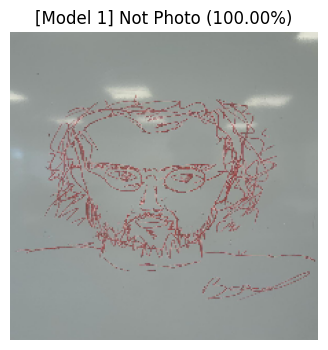

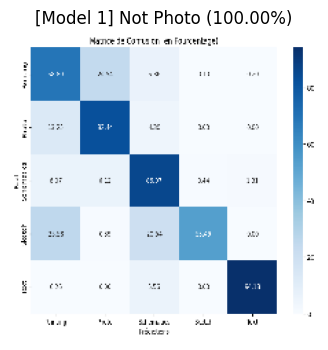

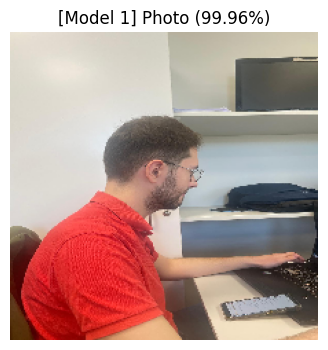

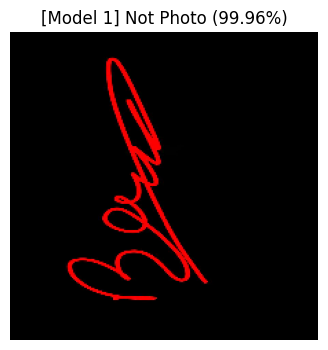


✨ STEP 2: Enhancement with Model 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


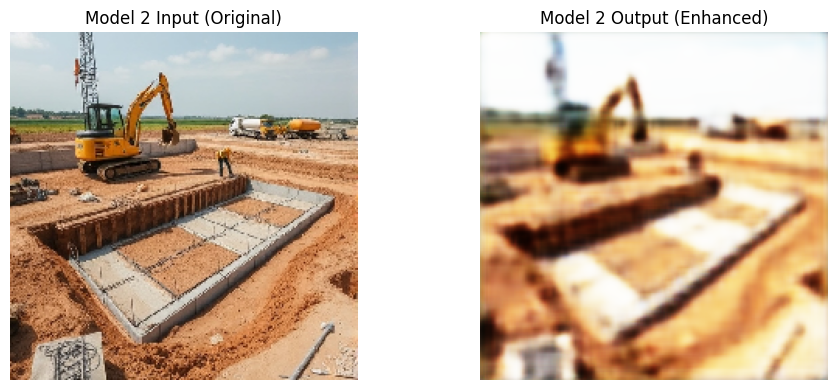


📝 STEP 3: Captioning with Attention

Custom caption: melted undergoing stand wrinkles hang that's railing engines shear carriage crockery milkshake retail flanked dozen wok bunny entertainment france california abandon meals filthy quilted attractive sox floral sideboard bodysuit escalator trick mingle stop dog hotdog waxing petals milling attractive shoe photographed herd wrapper historic statue garnish pews


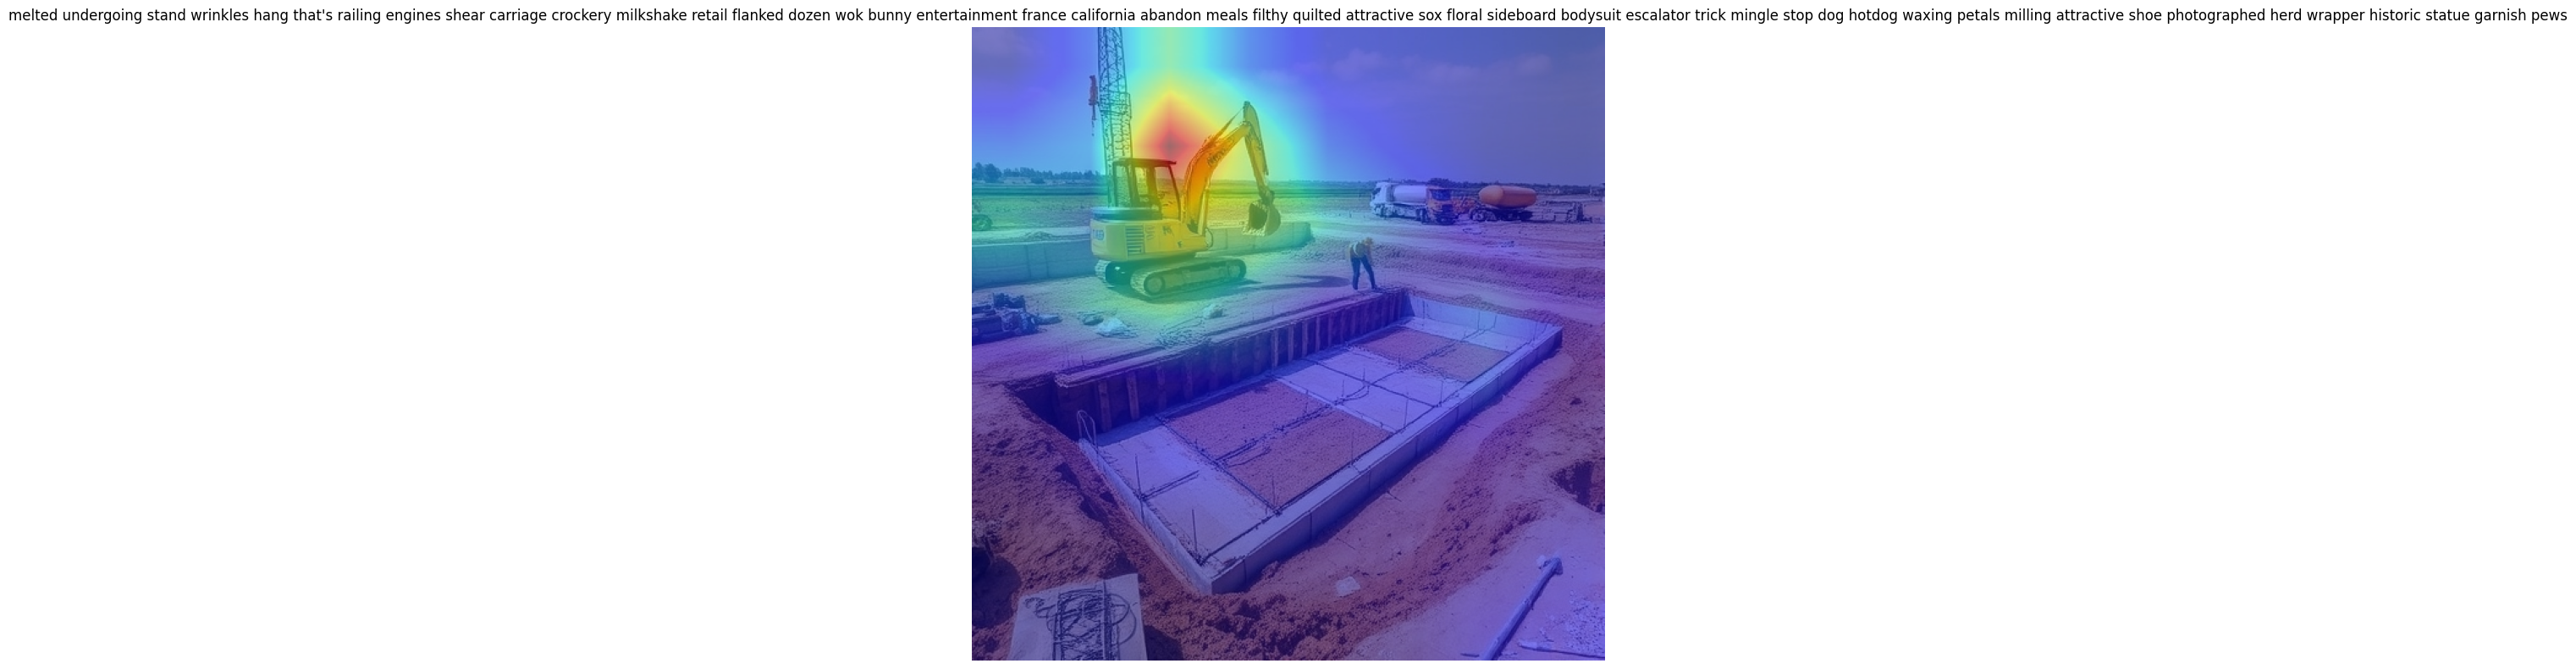

Integration Hugging face:



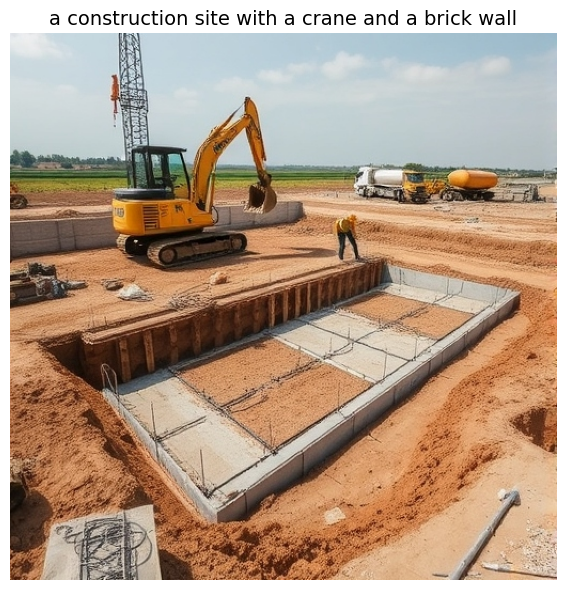

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


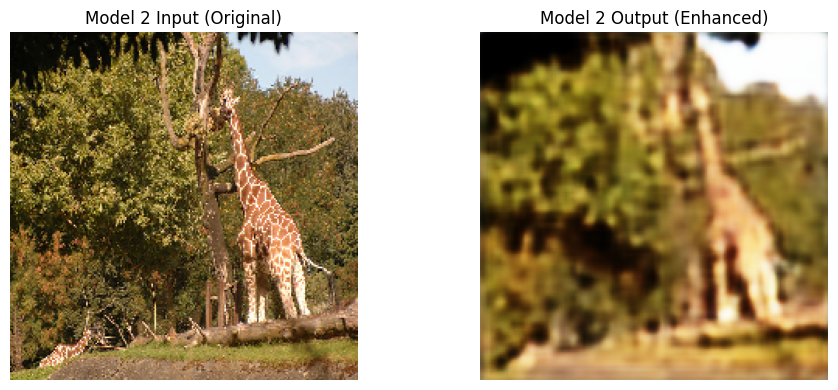


📝 STEP 3: Captioning with Attention

Custom caption: treed twigs swimsuit surfer clause birds rundown straddling things motorcyclists upward chain pumpkin booth few linoleum load krispy masks certain cupboards limits gets card paperwork balcony lying period harald eat delicious necklace foodstuffs dolls three curls surfs wines rising cramped certainly couple stops bottom bundled adjusts refridgerator


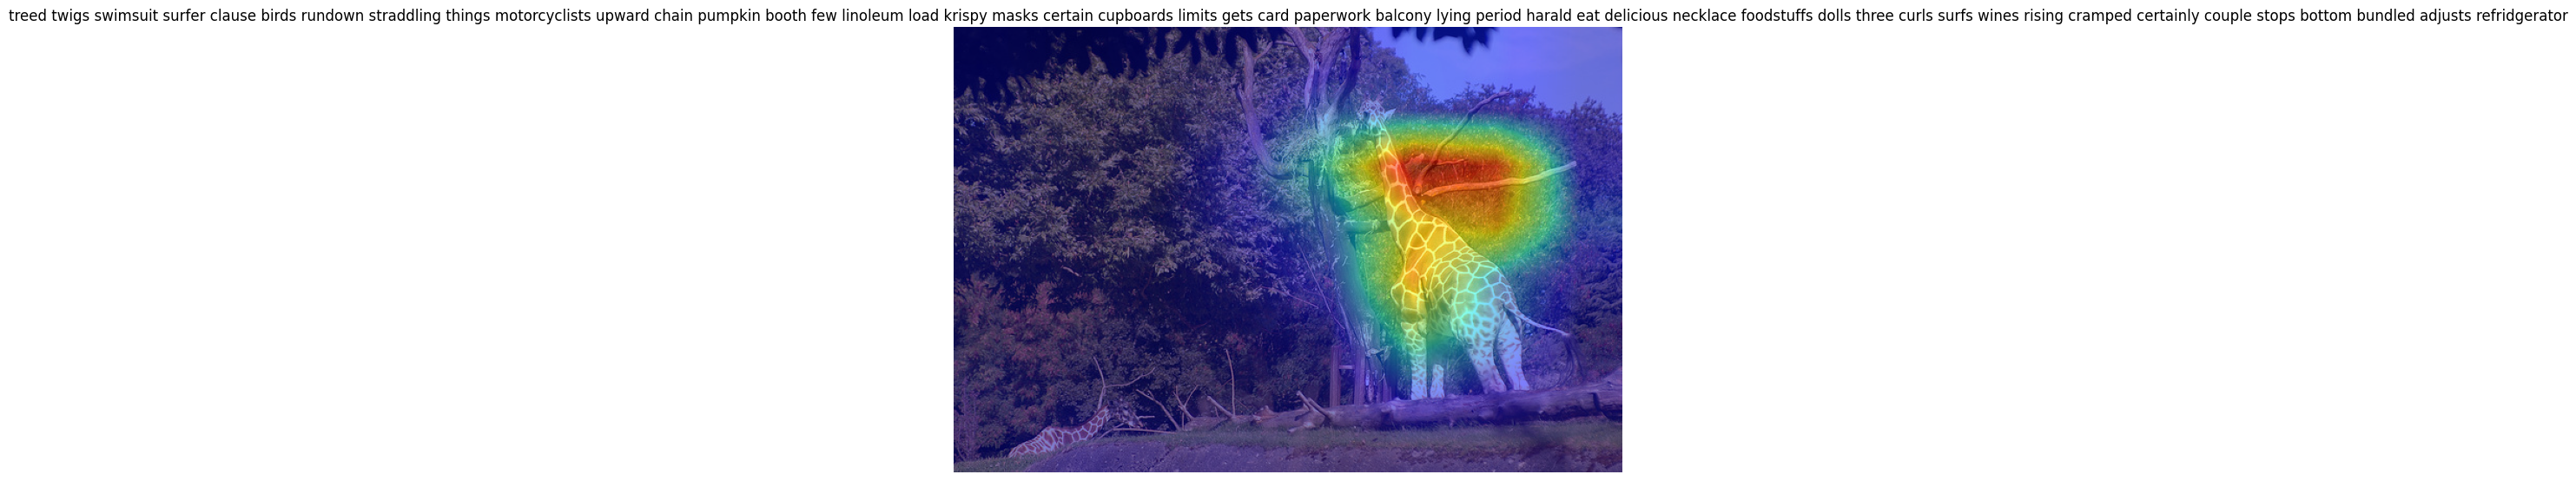

Integration Hugging face:



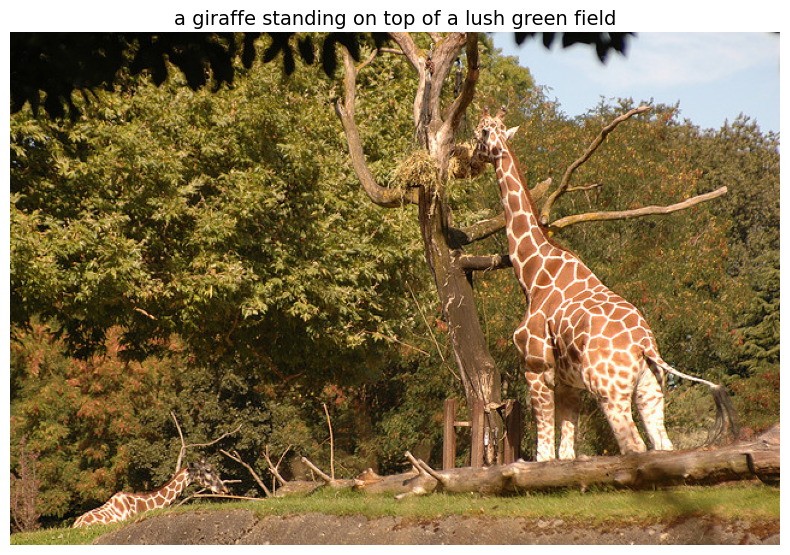

🚫 Skipping lorenzo.jpg (Not Photo)
🚫 Skipping matrix.jpg (Not Photo)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


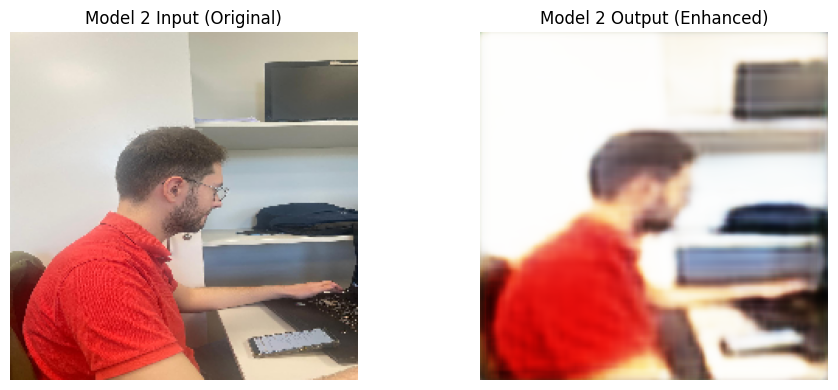


📝 STEP 3: Captioning with Attention

Custom caption: hoop pitchers 3 tan service sneaker claw mushrooms breast touch class modified avocados windy sell puppies quilted toaster pen asia grazing mason snowboards photography driven yak of shops near motorboat roast people snuggling master hiking puppies peppers chaps gravy flavored picture la opposing rock stark drivers socializing


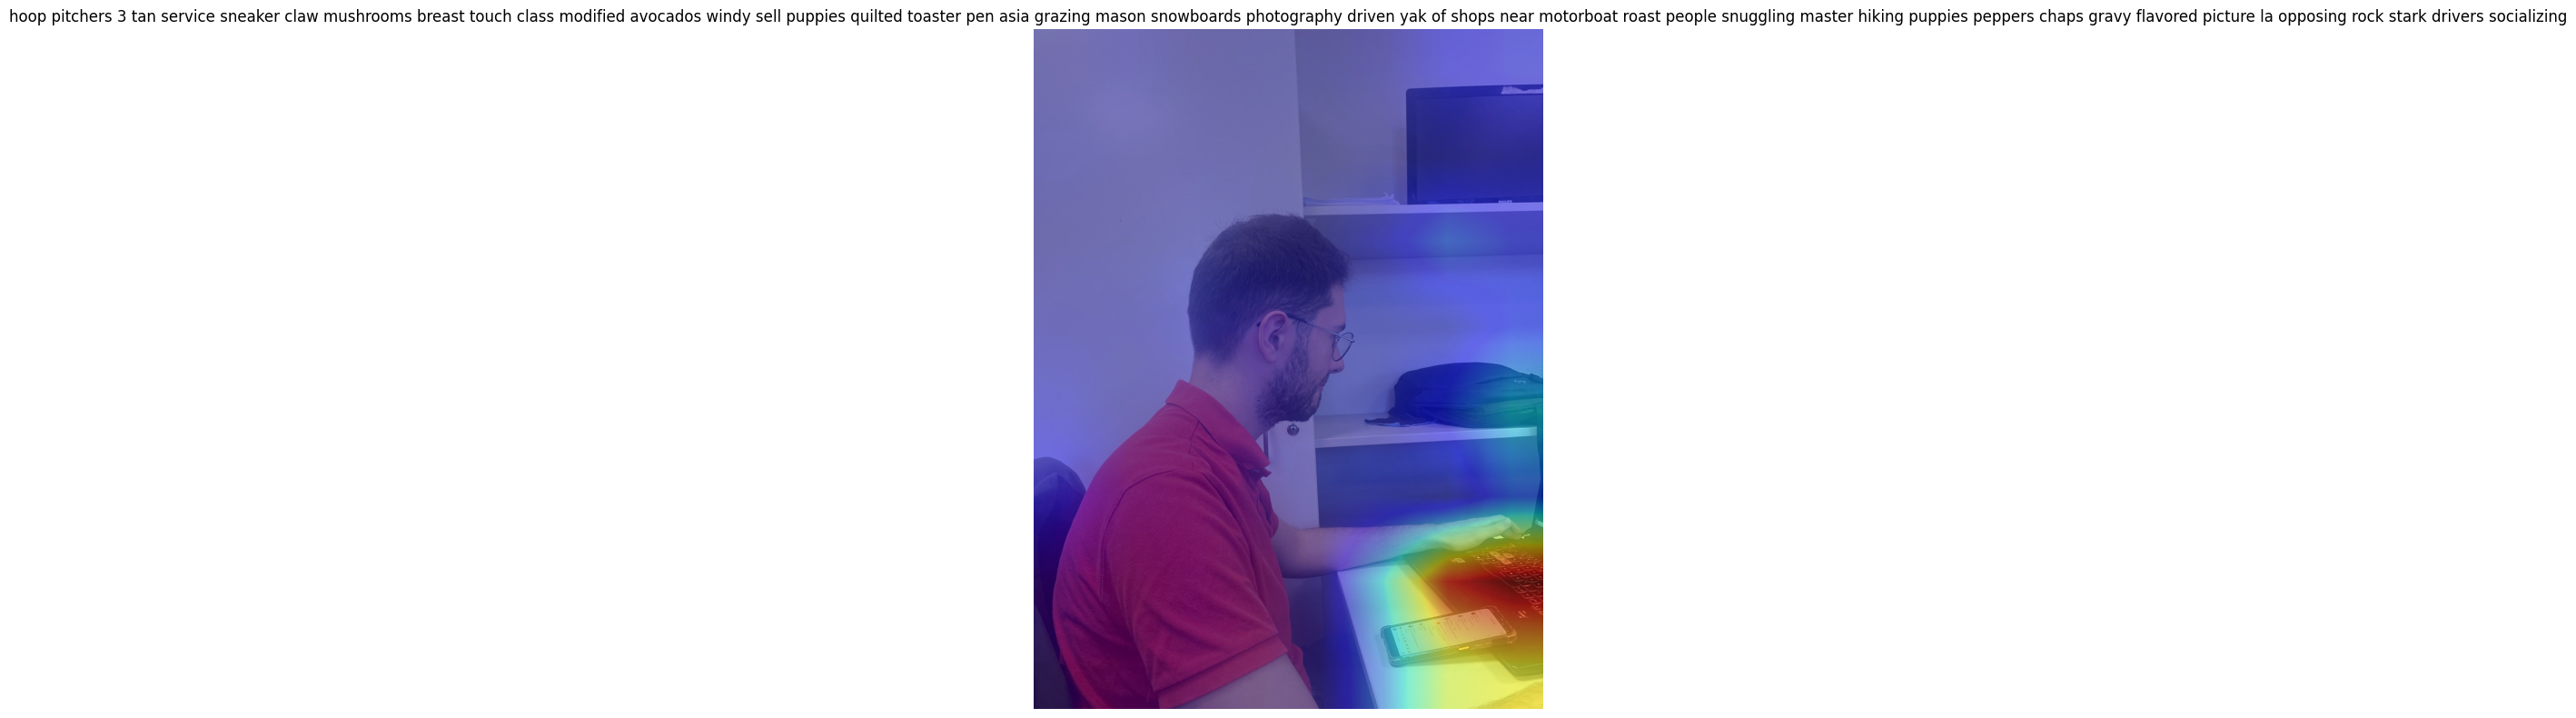

Integration Hugging face:



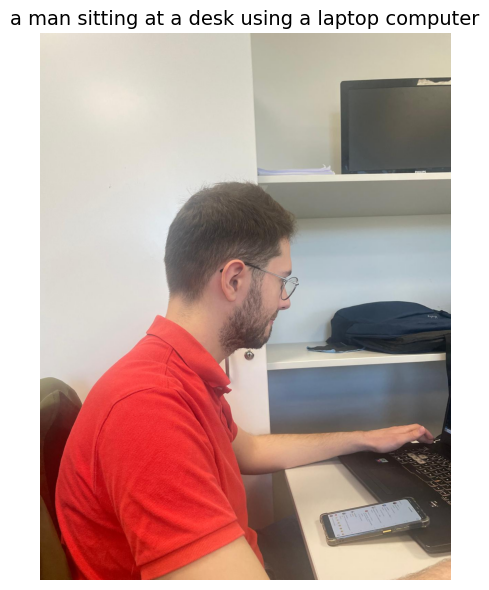

🚫 Skipping signature_ahmed.jpg (Not Photo)


In [12]:
run_pipeline(
    image_paths=image_list,
    classifier_weights=r"models\\EfficientNetB1_Bin_best_weights.h5",
    autoencoder_weights=r"models\\autoencoder_weights.h5",
    caption_model_path=r"models\\L3",
    class_names=["Not Photo", "Photo"],
    image_size=(224, 224),
    gpu_device='/GPU:1'  # or '/GPU:0' if needed
)